In [1]:
from typing import List,TypedDict,Literal
from dotenv import load_dotenv

from pydantic import BaseModel, Field
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma,FAISS
from langchain_huggingface import HuggingFaceEmbeddings,ChatHuggingFace,HuggingFaceEndpoint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import PydanticOutputParser

from langgraph.graph import StateGraph,END,START

load_dotenv()

C:\Users\adarsh\AppData\Local\Temp\ipykernel_18468\2241993529.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\adarsh\OneDrive\Desktop\langraph\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [33]:
docs=PyPDFLoader(r"C:\Users\adarsh\OneDrive\Desktop\langraph\SELF-RAG\Imaginary_Company_Profile.pdf").load()

In [34]:
chunks=RecursiveCharacterTextSplitter(chunk_size=100,chunk_overlap=10).split_documents(docs)

In [35]:
for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","igone")

In [36]:
emmbeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store=FAISS.from_documents(chunks,emmbeddings)
retriever=vector_store.as_retriever(search_kwargs={"k":3})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4173.03it/s]


In [7]:
llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
    max_new_tokens=2048
)

model=ChatHuggingFace(llm=llm,streaming=True)

In [29]:
class State(TypedDict):
    question:str

    need_retrieval:bool

    docs:List[Document]
    answer:str

In [24]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        ...,
        description="True if external documents are needed to answer reliably, False otherwise"
    )

parser=PydanticOutputParser(pydantic_object=RetrieveDecision)

decide_retrieval_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "you decide whether retrieval is needed.\n"
            "Return a JSON  object tht matches this schema:\n"
            "{{'should_retrieve':bool}}\n\n"
            "Guidelines:\n"
            "-should_retireve=True if the answering requires specific facts,citations or info likley not in the model\n"
            "should_retrieve=False for general explanations,definitions ore reasoning that does not need sources.\n"
            "-if unsure ,choose true"

            "{format_instructions}"
        ),
        ("human","Question:{question}"),

    ]
)

def decision_retrieve(state:State):

    question=state["question"]

    prompt_val=decide_retrieval_prompt.invoke(
        {
            "question":question,
            "format_instructions":parser.get_format_instructions()
        }
    )
    out=model.invoke(prompt_val)
    result=parser.parse(out.content)

    return {"need_retrieval":result.should_retrieve}


In [16]:
direct_generation_prompt=ChatPromptTemplate.from_messages(
    [
    (
        "system",
        "Answer the question using your general Knowledge.\n"
        "do Not assume acces to external document"
        "if you are ensure or the answer requires specific sources,say:\n"
        "I dont know based on my general Knowledge"
    ),
    ("human","question:{question}")
    ]

)

def generate_direct(state:State):

    template=direct_generation_prompt.invoke({"question":state["question"]})

    out=model.invoke(template)
    return{"answer":out.content}

In [14]:
def retrieve(state:State):
    return {"docs":retriever.invoke(state["question"])}

In [15]:
def route_after_decide(state:State):
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [37]:
g=StateGraph(State)
g.add_node("decision_retrieve",decision_retrieve)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)

g.add_edge(START,"decision_retrieve")
g.add_conditional_edges(
    "decision_retrieve",
    route_after_decide,
    {
        "retrieve":"retrieve",
        "generate_direct":"generate_direct"
    }
)
g.add_edge("generate_direct",END)
g.add_edge("retrieve",END)
app=g.compile()

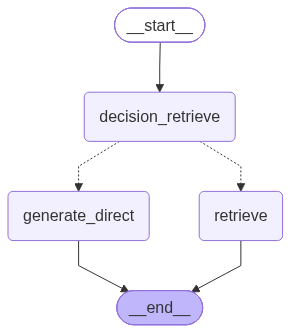

In [22]:
app

In [38]:
res=app.invoke(
    {
        "question":"what ar the polices of the company",
        "need_retrieval":False,
        "docs":[],
        "answer":""    
        }
)

In [27]:
print(res["answer"])

In [39]:
print(res["docs"])

[Document(id='60365755-a901-42aa-9ac1-e51afcfe5318', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\SELF-RAG\\Imaginary_Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='Employees must maintain professionalism, protect confidential information, follow company'), Document(id='88e0441d-be50-4bb9-8e65-93156046f638', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-05T03:51:53+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-05T03:51:53+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'C:\\Users\\adarsh\\OneDrive\\Desktop\\langraph\\S

In [43]:
print(res["need_retrieval"])

True


In [40]:
res2=app.invoke(
    {
        "question":"how cricket is played",
        "need_retrieval":False,
        "docs":[],
        "answer":""    
        }
)

In [41]:
print(res2["answer"])

Cricket is a bat-and-ball game played between two teams of eleven players on a field. The game is played with a ball and a bat. One team bats while the other bowls (throws) the ball and fields. The batting team scores runs by hitting the ball with the bat and running between two wickets (set 22 yards apart) located at either end of the pitch. The opposing team bowls and fields in an attempt to dismiss the batsmen and limit their scoring. A batsman is out when the ball is dismissed in a variety of ways. The team with more runs after both teams have had a turn at batting wins the game.


In [42]:
print(res2["need_retrieval"])

False
